# Ground Condition Prediction — Geo Map

Runs the **ground_condition_predictor** pipeline on `Kristian_dry_0425.csv`,  
takes the **left-foot** step predictions, time-aligns them to the GPX track,  
and plots each predicted step as a coloured marker on an interactive Folium map.

| Surface | Colour |
|---------|--------|
| Brick   | 🟠 orange |
| Concrete| 🔵 blue   |
| Grass   | 🟢 green  |


In [1]:
# Install dependencies if not already present
import subprocess, sys
for pkg in ['folium', 'scipy', 'scikit-learn', 'joblib']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)

## 0. Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET
import folium
from datetime import datetime, timezone, timedelta
from scipy.signal import find_peaks, savgol_filter
from scipy.stats import skew, kurtosis as scipy_kurtosis
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
import warnings; warnings.filterwarnings('ignore')

# ── File paths — adjust if needed ────────────────────────────────────
CSV_PATH     = 'Kristian_dry_0425.csv'
GPX_PATH     = 'activity_22645980458.gpx'
BRICK_PATH   = 'brick_dry.csv'
GRASS_PATH   = 'grass_dry.csv'
CONCRETE_PATH= 'concrete_dry.csv'

# ── Sensor / algorithm constants (from ground_condition_predictor) ────
HEEL_SENSORS     = ['pressure_08', 'pressure_11']
FOREFOOT_SENSORS = ['pressure_02', 'pressure_04', 'pressure_05',
                    'pressure_06', 'pressure_09']
ALL_SENSORS      = [f'pressure_{i:02d}' for i in range(1, 13)]
IMU_COLS         = ['accel_x','accel_y','accel_z',
                    'gyro_x','gyro_y','gyro_z','magn_x','magn_y','magn_z']

SMOOTH_WIN = 11; SMOOTH_POLY = 2; PEAK_DIST = 50; PEAK_PROM = 200; PEAK_HT = 500
SAMPLING_HZ = 62.5; HILL_WIN = 10; MIN_DP = 5

SURFACE_COLORS = {
    'grass': 'green', 'brick': 'orange', 'concrete': 'blue',
    'Grass': 'green', 'Brick': 'orange', 'Concrete': 'blue',
    'unknown': 'gray'
}

print('Imports OK.')

Imports OK.


## 1. Core Pipeline Functions

In [3]:
def preprocess(df):
    df = df.copy()
    df = df[df['corrupt'] == 0] if 'corrupt' in df.columns else df
    for c in ALL_SENSORS + IMU_COLS:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
    df = df.sort_values('timestamp').reset_index(drop=True)
    df['time_sec'] = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
    return df


def extract_step_features(df, surface_label='?', foot_label='left'):
    if df.empty or not all(s in df.columns for s in HEEL_SENSORS):
        return pd.DataFrame()

    heel = df[HEEL_SENSORS].sum(axis=1).values
    fore = df[FOREFOOT_SENSORS].sum(axis=1).values
    total= df[ALL_SENSORS].sum(axis=1).values

    smooth = savgol_filter(heel, SMOOTH_WIN, SMOOTH_POLY)
    peaks, _ = find_peaks(smooth, distance=PEAK_DIST,
                           prominence=PEAK_PROM, height=PEAK_HT)
    if len(peaks) < 2:
        return pd.DataFrame()

    t  = df['time_sec'].values
    ts = df['timestamp'].values   # raw ms epoch
    accel = df[['accel_x','accel_y','accel_z']].values
    rows  = []

    for i, pk in enumerate(peaks[:-1]):
        p1 = pk
        p2 = peaks[i+1]
        win_len = p2 - p1

        wh  = heel[p1:p2]; wf = fore[p1:p2]; wtp = total[p1:p2]
        wt  = t[p1:p2]
        wts = ts[p1:p2]  # timestamps for this step window

        diff = wf - wh
        m_loc = int(np.argmin(np.abs(diff)))
        c_loc = int(np.argmin(wh[:m_loc+1])) if m_loc > 0 else 0

        # impact magnitude
        wacc = accel[p1:p2]
        impact = float(np.max(np.linalg.norm(wacc, axis=1))) if len(wacc) > 0 else 0.0

        # loading rate
        lr_vals = []
        for hhi in range(1, min(HILL_WIN, len(wh) - c_loc)):
            hlo  = c_loc
            dt   = wt[hlo+hhi] - wt[hlo] if hlo+hhi < len(wt) else 0
            dp   = wh[hhi] - wh[0]
            if dt > 0 and dp >= MIN_DP:
                lr_vals.append(dp / dt)
        loading_rate = float(np.mean(lr_vals)) if lr_vals else 0.0

        per_s = {f'{s}_mean': float(df[s].values[p1:p2].mean())
                 if s in df.columns else 0.0 for s in ALL_SENSORS}
        hm = float(wh.mean()); fm = float(wf.mean())

        rows.append({
            'surface'        : surface_label,
            'foot'           : foot_label,
            'step_id'        : i + 1,
            'contact_time_sec': float(t[p1 + c_loc]),
            'contact_timestamp_ms': int(ts[p1 + c_loc]),  # <-- for geo alignment
            'stance_duration': float(wt[-1] - wt[0]) if len(wt) > 1 else 0.0,
            'impact_mag'     : impact,
            'loading_rate'   : loading_rate,
            'midstance_diff' : float(diff[m_loc - c_loc]),
            'heel_pmax'      : float(wh.max()),
            'fore_pmax'      : float(wf.max()),
            'heel_mean'      : hm,
            'fore_mean'      : fm,
            'total_pmax'     : float(wtp.max()),
            'heel_fore_ratio': hm / fm if fm > 0 else 1.0,
            **per_s,
        })
    return pd.DataFrame(rows)


FEATURE_COLS = [
    'impact_mag','loading_rate','midstance_diff',
    'heel_pmax','fore_pmax','total_pmax','heel_fore_ratio',
    'heel_mean','fore_mean','stance_duration',
] + [f'{s}_mean' for s in ALL_SENSORS]

print('Functions defined.')

Functions defined.


## 2. Train Model on Labelled Data

In [4]:
labelled = [
    (BRICK_PATH,    'brick'),
    (GRASS_PATH,    'grass'),
    (CONCRETE_PATH, 'concrete'),
]

tr_frames = []
for path, label in labelled:
    raw = pd.read_csv(path, low_memory=False)
    for sid, foot in [(1,'right'), (2,'left')]:
        df = preprocess(raw[raw['sole_id'] == sid])
        feats = extract_step_features(df, surface_label=label, foot_label=foot)
        if len(feats):
            tr_frames.append(feats)
    print(f'  {label}: loaded')

tr_df = pd.concat(tr_frames, ignore_index=True)
X_tr  = tr_df[FEATURE_COLS].fillna(0).values
y_tr  = tr_df['surface'].values
classes = sorted(set(y_tr))

clf = Pipeline([
    ('sc', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_cv   = cross_val_predict(clf, X_tr, y_tr, cv=cv)
cv_acc = accuracy_score(y_tr, y_cv)
print(f'\n5-Fold CV Accuracy: {cv_acc*100:.1f}%')
print(classification_report(y_tr, y_cv, digits=3))

clf.fit(X_tr, y_tr)
print('Model trained on full set.')

  brick: loaded
  grass: loaded
  concrete: loaded

5-Fold CV Accuracy: 92.8%
              precision    recall  f1-score   support

       brick      0.886     0.951     0.918        41
    concrete      0.947     0.947     0.947        57
       grass      0.946     0.875     0.909        40

    accuracy                          0.928       138
   macro avg      0.927     0.925     0.925       138
weighted avg      0.929     0.928     0.927       138

Model trained on full set.


## 3. Predict on Kristian's Run — Left Foot Only

In [5]:
kraw = pd.read_csv(CSV_PATH, low_memory=False)
print(f'Loaded {len(kraw)} rows | soles: {sorted(kraw["sole_id"].unique())}')

# Left foot = sole_id 2
df_left = preprocess(kraw[kraw['sole_id'] == 2])
left_feats = extract_step_features(df_left, surface_label='?', foot_label='left')
print(f'Left foot: {len(left_feats)} steps detected')

X_left = left_feats[FEATURE_COLS].fillna(0).values
left_feats['predicted_surface'] = clf.predict(X_left)
proba = clf.predict_proba(X_left)
for i, c in enumerate(classes):
    left_feats[f'prob_{c}'] = proba[:, i]
left_feats['max_confidence'] = proba.max(axis=1)

print('\nPrediction distribution:')
print(left_feats['predicted_surface'].value_counts())
print(f'Mean confidence: {left_feats["max_confidence"].mean()*100:.1f}%')
left_feats[['step_id','contact_time_sec','predicted_surface','max_confidence']].head(10)

Loaded 51267 rows | soles: [np.int64(1), np.int64(2)]
Left foot: 347 steps detected

Prediction distribution:
predicted_surface
brick       323
grass        13
concrete     11
Name: count, dtype: int64
Mean confidence: 52.2%


,step_id,contact_time_sec,predicted_surface,max_confidence
0,1,2.848,brick,0.440
1,2,4.128,brick,0.495
2,3,5.296,brick,0.440
3,4,5.936,brick,0.610
4,5,7.600,brick,0.485
5,6,8.896,brick,0.460
6,7,9.648,brick,0.500
7,8,11.408,brick,0.525
8,9,12.608,brick,0.490
9,10,13.744,brick,0.680


## 4. Parse GPX Track

In [6]:
GPX_NS = {'gpx': 'http://www.topografix.com/GPX/1/1'}

tree = ET.parse(GPX_PATH)
root = tree.getroot()

records = []
for pt in root.findall('.//gpx:trkpt', GPX_NS):
    t_elem = pt.find('gpx:time', GPX_NS)
    if t_elem is None:
        continue
    dt = datetime.fromisoformat(t_elem.text.replace('Z', '+00:00'))
    records.append({
        'lat'      : float(pt.attrib['lat']),
        'lon'      : float(pt.attrib['lon']),
        'datetime' : dt,
        'epoch_ms' : int(dt.timestamp() * 1000),
    })

gpx_df = pd.DataFrame(records)
print(f'GPX track points: {len(gpx_df)}')
print(f'  Start: {gpx_df["datetime"].iloc[0]}')
print(f'  End  : {gpx_df["datetime"].iloc[-1]}')
gpx_df.head(3)

GPX track points: 440
  Start: 2026-04-24 19:09:08+00:00
  End  : 2026-04-24 19:16:27+00:00


,lat,lon,datetime,epoch_ms
0,42.336990,-71.090600,2026-04-24 19:09:08+00:00,1777057748000
1,42.336982,-71.090596,2026-04-24 19:09:09+00:00,1777057749000
2,42.336983,-71.090596,2026-04-24 19:09:10+00:00,1777057750000


## 5. Time-Align Steps → GPS Positions

The insole timestamps are Unix epoch (ms). The GPX timestamps are also UTC.  
We find the nearest GPX point for each step's `contact_timestamp_ms`.

In [7]:
gpx_ms   = gpx_df['epoch_ms'].values
gpx_lats = gpx_df['lat'].values
gpx_lons = gpx_df['lon'].values

def nearest_gps(step_ms):
    """Return (lat, lon) of the GPX point closest in time to step_ms."""
    idx = np.argmin(np.abs(gpx_ms - step_ms))
    return gpx_lats[idx], gpx_lons[idx]

lats, lons = zip(*left_feats['contact_timestamp_ms'].map(nearest_gps))
left_feats['lat'] = lats
left_feats['lon'] = lons

# Sanity check: time delta between step and matched GPX point
matched_ms = []
for ms in left_feats['contact_timestamp_ms']:
    idx = np.argmin(np.abs(gpx_ms - ms))
    matched_ms.append(abs(gpx_ms[idx] - ms))
left_feats['gps_delta_ms'] = matched_ms

print('GPS alignment summary:')
print(f'  Median time delta to nearest GPX point: {np.median(matched_ms):.0f} ms')
print(f'  Max    time delta to nearest GPX point: {np.max(matched_ms):.0f} ms')
left_feats[['step_id','contact_time_sec','predicted_surface',
            'max_confidence','lat','lon','gps_delta_ms']].head(8)

GPS alignment summary:
  Median time delta to nearest GPX point: 240 ms
  Max    time delta to nearest GPX point: 496 ms


,step_id,contact_time_sec,predicted_surface,max_confidence,lat,lon,gps_delta_ms
0,1,2.848,brick,0.440,42.336983,-71.090596,208
1,2,4.128,brick,0.495,42.336983,-71.090606,72
2,3,5.296,brick,0.440,42.336989,-71.090607,240
3,4,5.936,brick,0.610,42.336998,-71.090614,120
4,5,7.600,brick,0.485,42.337002,-71.090650,456
5,6,8.896,brick,0.460,42.337009,-71.090664,160
6,7,9.648,brick,0.500,42.337014,-71.090676,408
7,8,11.408,brick,0.525,42.337021,-71.090689,352


## 6. Interactive Folium Map

In [ ]:
MAPBOX_TOKEN = "pk.eyJ1IjoiY2F0eiIsImEiOiJjbW9seTM1YmYwcjFlMzFva2Q2YTlxNW0yIn0.QuazdjwpiW9WqUTZAQxd3w"

# Test with a known-good Mapbox style first
mapbox_tiles = (
    f"https://api.mapbox.com/styles/v1/mapbox/satellite-streets-v12/tiles/256/{{z}}/{{x}}/{{y}}@2x"
    f"?access_token={MAPBOX_TOKEN}"
)

In [2]:
# ── Centre map on the mean GPS position ──────────────────────────────
center_lat = gpx_df['lat'].mean()
center_lon = gpx_df['lon'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=17,
    tiles=None  
)

folium.TileLayer(
    tiles=mapbox_tiles,
    attr="© Mapbox © OpenStreetMap",
    name="Mapbox Custom Style"
).add_to(m)

# ── Draw the GPX route as a polyline ─────────────────────────────────
route_coords = list(zip(gpx_df['lat'], gpx_df['lon']))
folium.PolyLine(
    route_coords,
    color='#555555',
    weight=2.5,
    opacity=0.55,
    tooltip='GPS Track',
).add_to(m)

# ── Start / End markers ───────────────────────────────────────────────
folium.Marker(
    location=route_coords[0],
    popup='Start',
    icon=folium.Icon(color='darkblue', icon='play', prefix='fa'),
).add_to(m)

folium.Marker(
    location=route_coords[-1],
    popup='End',
    icon=folium.Icon(color='red', icon='stop', prefix='fa'),
).add_to(m)

# ── One FeatureGroup per surface class ───────────────────────────────
groups = {s: folium.FeatureGroup(name=s.capitalize()) for s in classes}

for _, row in left_feats.iterrows():
    surf = row['predicted_surface']
    conf = row['max_confidence']
    color = SURFACE_COLORS.get(surf, 'gray')

    # Radius scales with confidence (5–12 px)
    radius = 5 + int(conf * 7)

    popup_html = (
        f"<b>Step {int(row['step_id'])}</b><br>"
        f"Surface: <b>{surf.capitalize()}</b><br>"
        f"Confidence: {conf*100:.1f}%<br>"
        f"Time: {row['contact_time_sec']:.1f} s<br>"
        f"Impact: {row['impact_mag']:.0f}<br>"
        f"GPS Δ: {row['gps_delta_ms']:.0f} ms"
    )

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.75,
        popup=folium.Popup(popup_html, max_width=200),
        tooltip=f"{surf.capitalize()} ({conf*100:.0f}%)",
    ).add_to(groups[surf])

for grp in groups.values():
    grp.add_to(m)

# ── Legend ────────────────────────────────────────────────────────────
legend_html = """
<div style="
    position: fixed;
    bottom: 40px; left: 40px; z-index: 1000;
    background: white; padding: 12px 16px;
    border-radius: 8px; border: 1px solid #ccc;
    font-family: sans-serif; font-size: 13px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.2);">
  <b>Ground Condition</b><br>
  <span style="color:green;">●</span> Grass<br>
  <span style="color:orange;">●</span> Brick<br>
  <span style="color:blue;">●</span> Concrete<br>
  <small style="color:#888;">Left foot · marker size = confidence</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# ── Layer control ─────────────────────────────────────────────────────
folium.LayerControl(collapsed=False).add_to(m)

# ── Save & display ────────────────────────────────────────────────────
out_html = 'ground_condition_geo_map.html'
m.save(out_html)
print(f'Map saved → {out_html}')

# Display inline in Jupyter
from IPython.display import IFrame
IFrame(out_html, width='100%', height=620)

NameError: name 'gpx_df' is not defined

## 7. Summary Statistics

=== Left Foot Prediction Summary ===
                   steps  mean_confidence  mean_impact  mean_stance_ms
predicted_surface                                                     
brick                323            0.532    46702.376           1.115
concrete              11            0.379    42859.341           1.670
grass                 13            0.391    39508.703           1.778


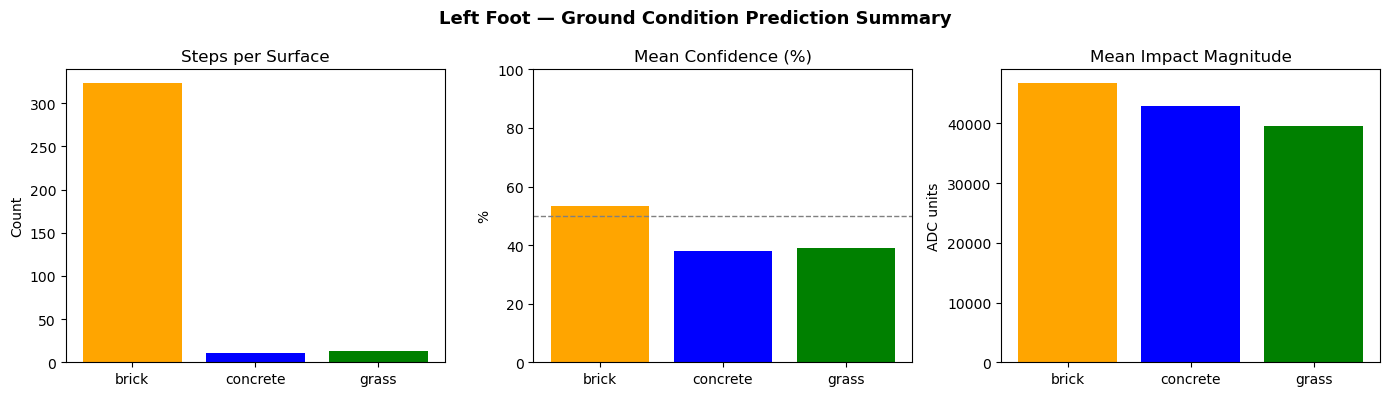

Summary chart saved → ground_condition_summary.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print('=== Left Foot Prediction Summary ===')
summary = left_feats.groupby('predicted_surface').agg(
    steps=('step_id','count'),
    mean_confidence=('max_confidence','mean'),
    mean_impact=('impact_mag','mean'),
    mean_stance_ms=('stance_duration','mean')
).round(3)
print(summary.to_string())

# Quick bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Left Foot — Ground Condition Prediction Summary', fontsize=13, fontweight='bold')

bar_colors = [SURFACE_COLORS[s] for s in summary.index]

axes[0].bar(summary.index, summary['steps'], color=bar_colors)
axes[0].set_title('Steps per Surface'); axes[0].set_ylabel('Count')

axes[1].bar(summary.index, summary['mean_confidence']*100, color=bar_colors)
axes[1].set_title('Mean Confidence (%)'); axes[1].set_ylabel('%'); axes[1].set_ylim(0, 100)
axes[1].axhline(50, color='gray', ls='--', lw=1)

axes[2].bar(summary.index, summary['mean_impact'], color=bar_colors)
axes[2].set_title('Mean Impact Magnitude'); axes[2].set_ylabel('ADC units')

plt.tight_layout()
plt.savefig('ground_condition_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Summary chart saved → ground_condition_summary.png')